In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

os.chdir(r"C:\Users\PREM\OneDrive\Desktop\Bluestock_MF_Capstone")

PROC = Path("data/processed")
RAW  = Path("data/raw")

print("Setup complete!")

Setup complete!


In [3]:
nav_history = pd.read_csv(PROC / "clean_nav.csv",        parse_dates=["date"])
fund_master = pd.read_csv(RAW  / "01_fund_master.csv")
benchmarks  = pd.read_csv(RAW  / "10_benchmark_indices.csv", parse_dates=["date"])

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

print("Files loaded!")

Files loaded!


In [4]:
cagr_results = []

for code, grp in nav_history.groupby("amfi_code"):
    grp       = grp.sort_values("date")
    start_nav = grp["nav"].iloc[0]
    end_nav   = grp["nav"].iloc[-1]
    n_years   = len(grp) / 252

    cagr = (end_nav / start_nav) ** (1 / n_years) - 1

    cagr_results.append({
        "amfi_code": code,
        "cagr_pct" : round(cagr * 100, 2)
    })

cagr_df = pd.DataFrame(cagr_results).sort_values("cagr_pct", ascending=False)
print("CAGR computed!")
cagr_df.head(10)

CAGR computed!


,amfi_code,cagr_pct
25,120505,31.48
21,119598,31.10
39,149324,30.97
36,148569,30.64
34,148567,29.71
30,120843,29.65
2,100033,28.90
38,149323,28.38
16,119094,27.08
19,119551,24.77


In [5]:
RF_DAILY = 0.065 / 252

sharpe_results = []

for code, grp in nav_history.groupby("amfi_code"):
    rets = grp["daily_return"].dropna()
    if len(rets) < 50:
        continue
    sharpe = ((rets - RF_DAILY).mean() / rets.std()) * (252 ** 0.5)
    sharpe_results.append({"amfi_code": code, "sharpe_ratio": round(sharpe, 4)})

sharpe_df = pd.DataFrame(sharpe_results).sort_values("sharpe_ratio", ascending=False)
print("Sharpe Ratio computed!")
sharpe_df.head(10)

Sharpe Ratio computed!


,amfi_code,sharpe_ratio
34,148567,1.4483
30,120843,1.3067
36,148569,1.2349
19,119551,1.2083
25,120505,1.1801
38,149323,1.1321
2,100033,1.0937
9,118632,1.0817
3,101206,1.0272
24,120504,1.0265


In [6]:
dd_results = []

for code, grp in nav_history.groupby("amfi_code"):
    nav    = grp.sort_values("date")["nav"]
    max_dd = ((nav - nav.cummax()) / nav.cummax()).min()
    dd_results.append({"amfi_code": code, "max_drawdown_pct": round(max_dd * 100, 2)})

dd_df = pd.DataFrame(dd_results).sort_values("max_drawdown_pct")
print("Max Drawdown computed!")
dd_df.head(10)

Max Drawdown computed!


,amfi_code,max_drawdown_pct
22,119599,-52.57
17,119095,-51.68
4,101207,-35.45
39,149324,-31.17
21,119598,-28.71
7,102886,-28.00
0,100016,-24.73
29,120842,-24.00
11,118634,-23.34
15,119093,-21.75


In [7]:
nifty = benchmarks[benchmarks["index_name"] == "NIFTY50"].copy()
nifty["bench_ret"] = nifty["close_value"].pct_change()
nifty = nifty[["date", "bench_ret"]].dropna()

ab_results = []

for code, grp in nav_history.groupby("amfi_code"):
    grp    = grp.sort_values("date")[["date", "daily_return"]].dropna()
    merged = grp.merge(nifty, on="date", how="inner")
    if len(merged) < 50:
        continue
    slope, intercept, _, _, _ = stats.linregress(
        merged["bench_ret"], merged["daily_return"]
    )
    ab_results.append({
        "amfi_code": code,
        "alpha"    : round(intercept * 252, 4),
        "beta"     : round(slope, 4)
    })

ab_df = pd.DataFrame(ab_results)
print("Alpha & Beta computed!")
ab_df.head(10)

Alpha & Beta computed!


,amfi_code,alpha,beta
0,100016,0.0362,-0.0259
1,100025,0.0432,-0.0162
2,100033,0.2723,-0.0112
3,101206,0.2139,0.0338
4,101207,0.1082,-0.0599
5,101208,0.0608,0.0013
6,102885,0.1699,-0.0019
7,102886,0.0289,-0.0615
8,102887,0.1618,0.0401
9,118632,0.2173,0.0364


In [8]:
scorecard = cagr_df.merge(sharpe_df, on="amfi_code")
scorecard = scorecard.merge(dd_df,   on="amfi_code")
scorecard = scorecard.merge(ab_df,   on="amfi_code")
scorecard = scorecard.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house",
                 "category", "expense_ratio_pct"]],
    on="amfi_code"
)

n = len(scorecard)
scorecard["score"] = (
    0.30 * scorecard["cagr_pct"].rank()           / n * 100 +
    0.25 * scorecard["sharpe_ratio"].rank()        / n * 100 +
    0.20 * scorecard["alpha"].rank()               / n * 100 +
    0.15 * scorecard["expense_ratio_pct"].rank(ascending=False) / n * 100 +
    0.10 * scorecard["max_drawdown_pct"].rank(ascending=False)  / n * 100
).round(2)

scorecard = scorecard.sort_values("score", ascending=False)
scorecard.to_csv(PROC / "fund_scorecard.csv", index=False)

print("Scorecard saved!")
scorecard[["scheme_name", "cagr_pct", "sharpe_ratio", "alpha", "score"]].head(10)

Scorecard saved!


,scheme_name,cagr_pct,sharpe_ratio,alpha,score
0,ICICI Pru Midcap Fund - Regular - Growth,31.48,1.1801,0.2930,87.50
1,SBI Small Cap Fund - Regular Plan - Growth,31.10,0.9453,0.3011,82.62
2,DSP Small Cap Fund - Regular - Growth,30.97,0.9498,0.2982,80.19
5,Kotak Flexicap Fund - Regular - Growth,29.65,1.3067,0.2728,79.00
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,28.90,1.0937,0.2723,78.25
4,Mirae Asset Large Cap Fund - Regular - Growth,29.71,1.4483,0.2712,77.75
3,Mirae Asset Tax Saver Fund - Regular - Growth,30.64,1.2349,0.2835,76.94
8,Axis Midcap Fund - Regular - Growth,27.08,0.9982,0.2600,74.75
9,SBI Bluechip Fund - Regular Plan - Growth,24.77,1.2083,0.2322,70.06
10,Nippon India Large Cap Fund - Regular - Growth,23.09,1.0817,0.2173,70.06


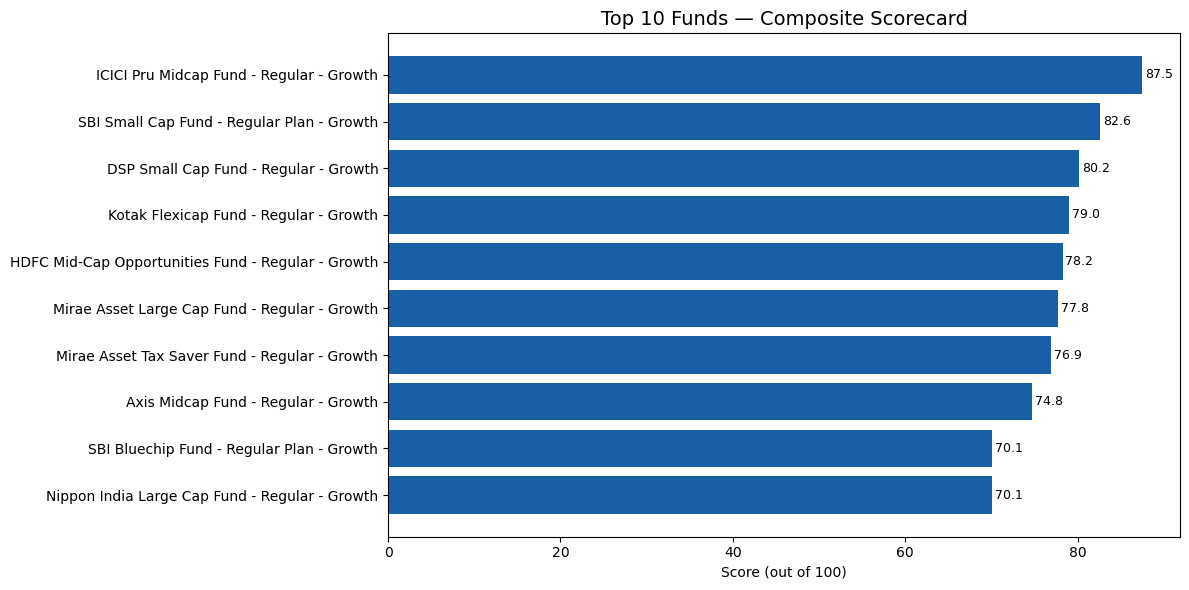

Chart saved!


In [10]:
top10 = scorecard.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10["scheme_name"], top10["score"], color="#185fa5")
plt.title("Top 10 Funds — Composite Scorecard", fontsize=14)
plt.xlabel("Score (out of 100)")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.1f}",
             va="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/chart6_scorecard.png")
plt.show()
print("Chart saved!")